<h1 align="center">Medical costs dataset</h1>

<h2 align="center">Introduction</h2>
<p>this dataset is known for having linear relationships on top of wich you can build regressions , thus, this will be my goal in this project, I am going to experiment and hopefully learn how to properly use a regression for predicting an output and later attempt different models as well.<br>

<style>
  ol {
    list-style-type: none;
    counter-reset: item -1;
  }
  ol li {
    display: block;
  }
  ol li:before {
    content: counters(item, ".") " ";
    counter-increment: item;
    font-weight: bold;
  }
  ol ol {
    counter-reset: item 0;
  }
</style>

<ol>
  <li>Dataset importing</li>
  <li>Data Visualisation <ol>
      <li>age graphics
       <ol>
          <li>Histogram of ages </li>
          <li>Histogram of ages by sex</li>
          <li>Histogram of ages by smoker status</li>
          <li>Histogram of ages by region</li>
       </ol>
      </li>
      <li> bmi graphics
        <ol>
          <li>Histogram of bmis </li>
          <li>Histogram of bmi by sex</li>
          <li>Histogram of bmi by smoker status</li>
          <li>Histogram of bmi by region</li>
        </ol>
      </li>
      <li> charges graphics
        <ol>
          <li>Histogram of charges </li>
          <li>Histogram of charges by sex</li>
          <li>Histogram of charges by smoker status</li>
          <li>Histogram of charges by region</li>
        </ol>
      </li>
  </li>
  </ol>
  <li>Relationships between data</li>
    <ol>
        <li> Correlation heatmap </li>
        <li> Scatterplot of bmi and age </li>
        <li> Scatterplot of bmi and southwest </li>
        <li> Scatterplot of charges and bmi </li>
        <li>Age and charges scatterplot</li>
        <li>Charges by age for each location</li>
    </ol>
</ol


<h2 align="center"> Dataset description and importing </h2>
<p> the dataset was found in "Machine Learning with R" by Brett Lantz, it was cleaned up and published on kaggle by Miri Choi (mirichoi0218)<br>
<p> contents :</p>
<ul>
  <li>Age - ages of the beneficiary, integers ranging from 18 to 64 </li>
  <li>Sex - male and female, initially strings </li>
  <li>BMI - body mass index ranging from 15.96 to 53.13</li>
  <li>Children - number of children registered, from 0 to 5</li>
  <li>Smoker Status - initially yes and no strings</li>
  <li>Region - initially southwest, southeast, nothwest, notheast strings</li>
  <li>Charges - individual bills from health insurance, from 1121.87 63770.42
</ul>
<p> these fields will be later be manipulated according to the needs of the project
<p> first modification : changed sex and smoker status to dummy variables in order to incorporate them in my models


In [637]:
from copy import deepcopy
import pandas as pd
import kagglehub
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
path = r"C:\Users\dariu\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1\insurance.csv"
df = pd.read_csv(path)


path = kagglehub.dataset_download("mirichoi0218/insurance")
df = pd.read_csv(f"{path}/insurance.csv")
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})


# uncomment this if you are running from another device
# path = kagglehub.dataset_download("mirichoi0218/insurance")
# csv_path = os.path.join(path, "insurance.csv")
# df = pd.read_csv(csv_path)
# print(df.head())


#this will be used
auxdf = deepcopy(df)

<h2 align="center">1.1 Age graphics</h2>
<p style="text-align: center;"> below you will find multiple graphics describing ages and it s relationships with data </p>

<h4 align="center">1.1.1 Ages histogram</h4>
<p> the average age is 39 overall, as you can see, the number of 20 years olds is much greater than any other age <br>
<p> the standard deviation is $\sigma = 14 $ resulting in a  $-1\sigma$ and $+1\sigma$ range of 28.08 ranging from 25 to 53

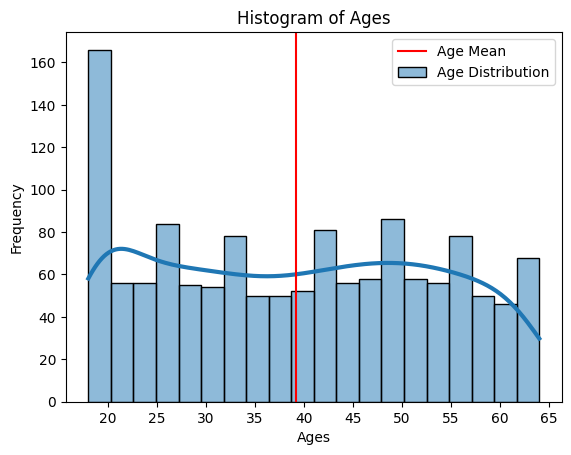

In [638]:
ageMean= df["age"].mean()
ageDeviation = df["age"].std()
x= ageMean - ageDeviation
y =ageMean + ageDeviation

plt.figure()
plt.grid(False)
sns.histplot(data=df, x="age", bins=20, edgecolor="black", kde=True,line_kws={"color": "purple", "linewidth": 3},label="Age Distribution")
plt.xticks(range(20,66,5))
plt.xlabel("Ages")
plt.ylabel("Frequency")
plt.axvline(x=ageMean, color="red",label="Age Mean")
plt.legend()
plt.title("Histogram of Ages")
plt.show()

<h4 align="center">1.1.2 Ages histogram by sex </h4>
<p> as you can see below, the difference between male and female ages are similar, having roughly the same amount of data for both cathegories

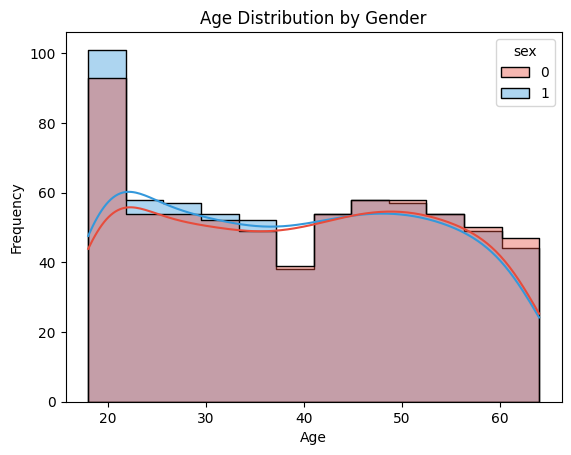

In [639]:
plt.figure()
plt.grid(False)
sns.histplot(data=df, x="age", hue="sex",edgecolor = "black", kde=True, palette={1: "#3498db", 0: "#e74c3c"}, alpha=0.4, element="step")
plt.xlabel("Ages")
plt.ylabel("Frequency")
plt.title("Age Distribution by Gender")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

<h4 align="center">1.1.3 Ages of smokers vs non smokers </h4>
<p>

<Figure size 640x480 with 0 Axes>

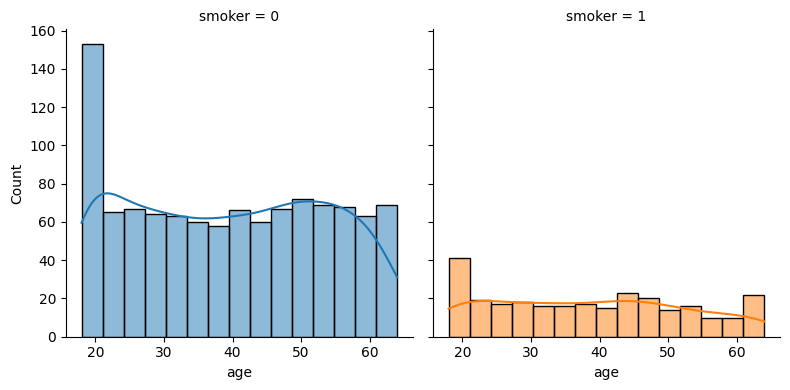

In [640]:
plt.figure()
g = sns.FacetGrid(df, col="smoker", hue="smoker", height=4, aspect=1)
g.map(sns.histplot, "age", kde=True,bins=15)

<h4 align="center">1.1.4 Ages of people from different regions </h4>
<p>

<Figure size 640x480 with 0 Axes>

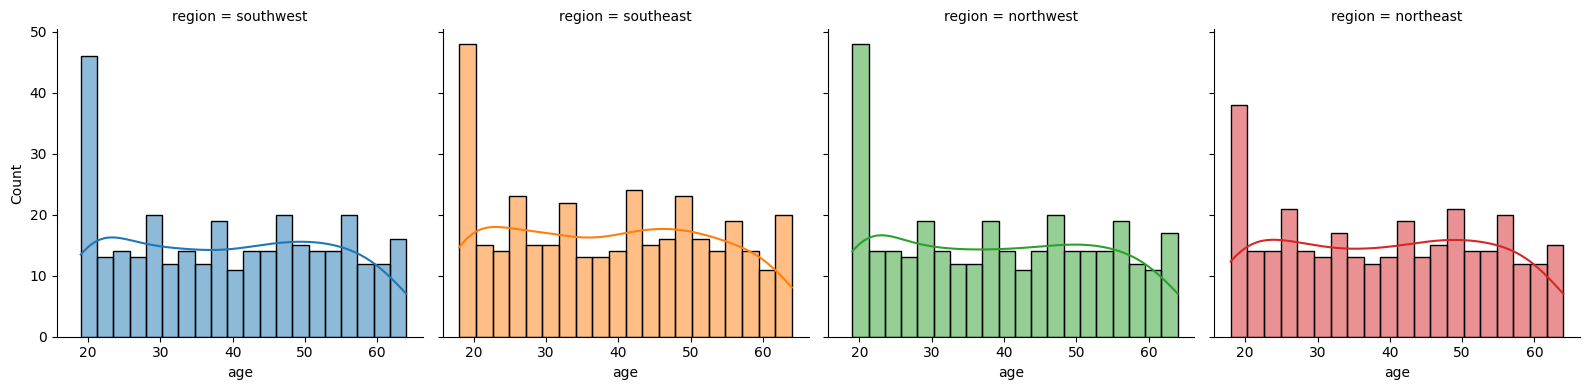

In [641]:
plt.figure()
g = sns.FacetGrid(df, col="region", hue="region", height=4, aspect=1)
g.map(sns.histplot, "age", kde=True,bins = 20)
# meanSW = df.loc[df['region'] == 'southwest', 'age'].mean()
# print(meanSW)

<h2 align="center">1.2 BMI graphics </h2>

<h4 align="center">1.2.1 histogram of BMI s </h4>

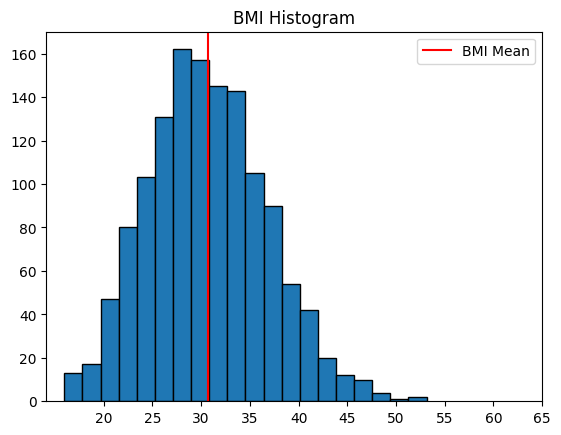

In [642]:
plt.figure()
plt.grid(False)
bmiMean= df["bmi"].mean()
plt.hist(df["bmi"],bins = 20,edgecolor="black")
plt.xticks(range(20,66,5))
plt.title("BMI Histogram")
plt.axvline(x=bmiMean, color="red",label="BMI Mean")
plt.legend()

<h4 align="center">1.2.2 Histogram of bmi by sex</h4>

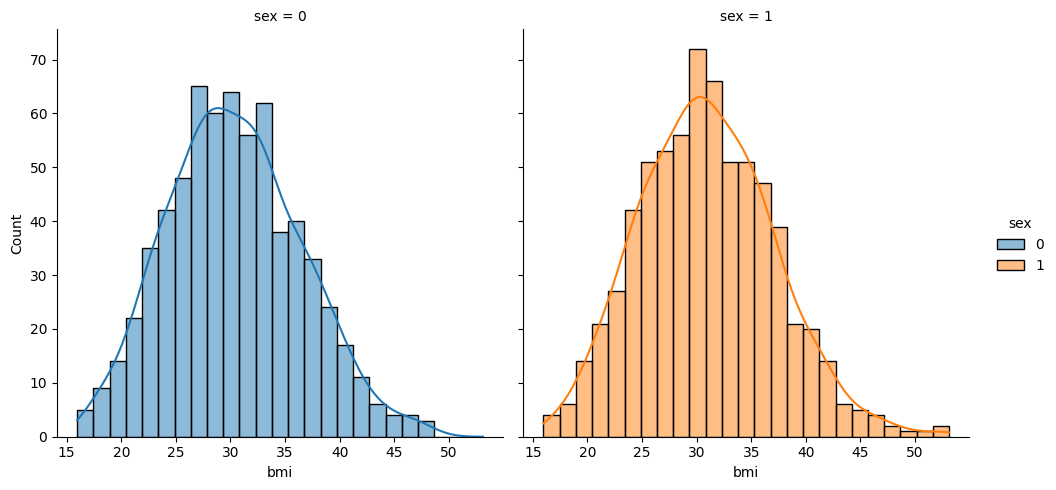

In [643]:
g = sns.displot(data = df, x = "bmi", col = "sex",hue ="sex", kind= "hist", kde = True, aspect=1)

<h4 align="center">1.2.3 Histogram of bmi by smoker status</h4>

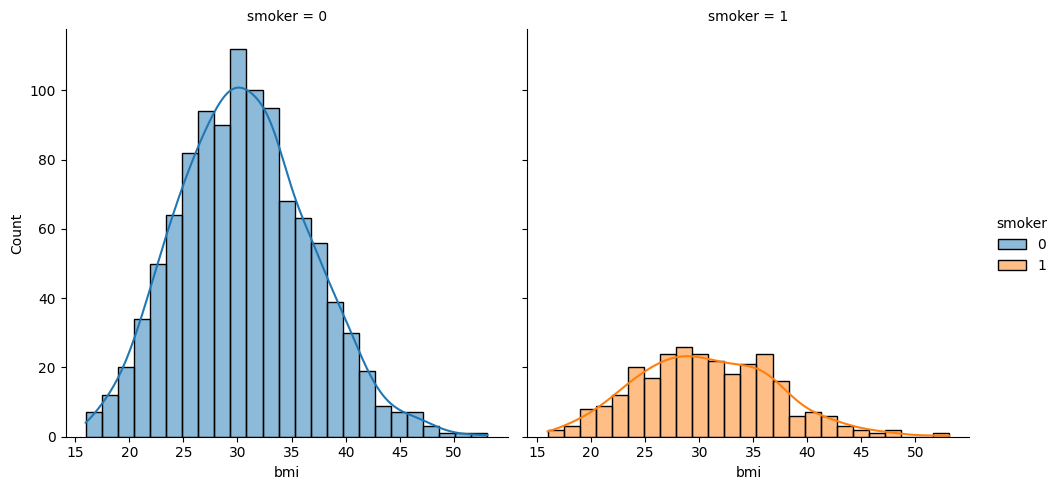

In [644]:
g = sns.displot(data = df, x = "bmi", col = "smoker",hue ="smoker", kind= "hist", kde = True, aspect=1)

<h4 align="center">1.2.4 Histogram of bmi by charges</h4>

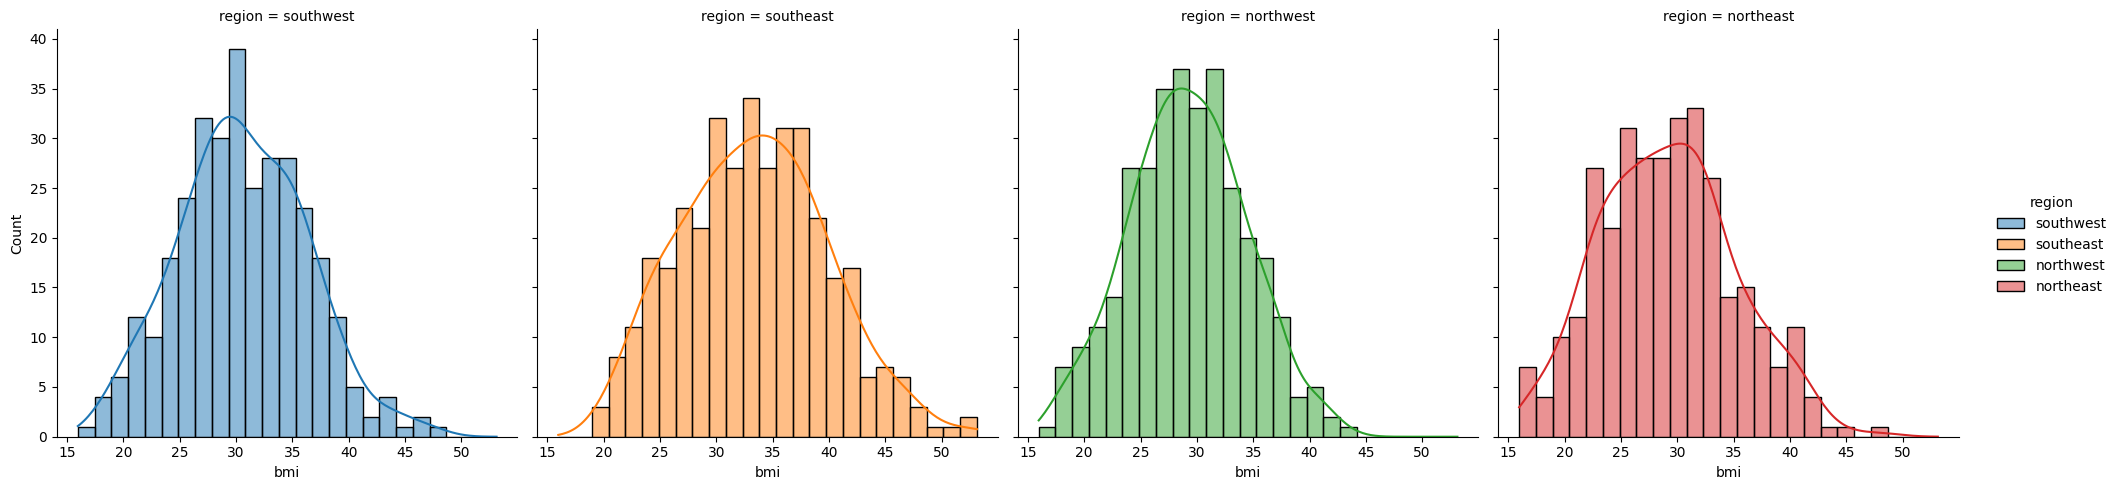

In [645]:
# g = sns.FacetGrid(df, col="region", aspect=1)
# g.map(sns.histplot, "bmi", kde=True)
# g.set(xticks= range(20,66,5))
g = sns.displot(data = df,x="bmi",col="region",hue="region",kind="hist",kde=True,aspect=1)
plt.show()


<h2 align="center">1.3 charges graphics</h2>

<h4 align = "center">1.3.1 Histogram of charges </h4>

Text(0.5, 1.0, 'Histogram of Charges')

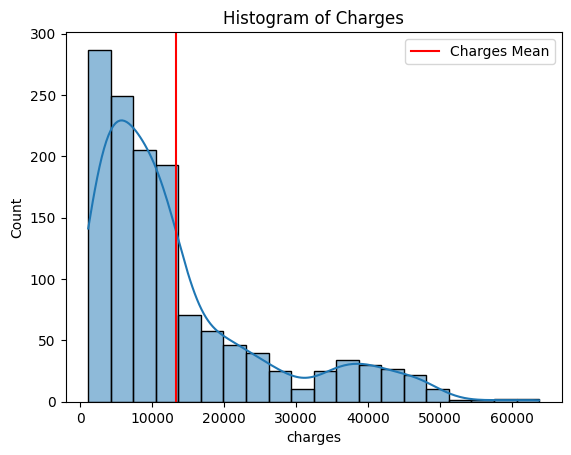

In [646]:
plt.figure()
plt.grid(False)
sns.histplot(data = df, x = "charges", bins = 20, edgecolor = "black", kde = True)
chargeMean = np.mean(df["charges"])
plt.axvline(x=chargeMean, color="red",label="Charges Mean")
plt.legend()
plt.title("Histogram of Charges")

<h4 align = "center">1.3.2 Histogram of charges by sex </h4>

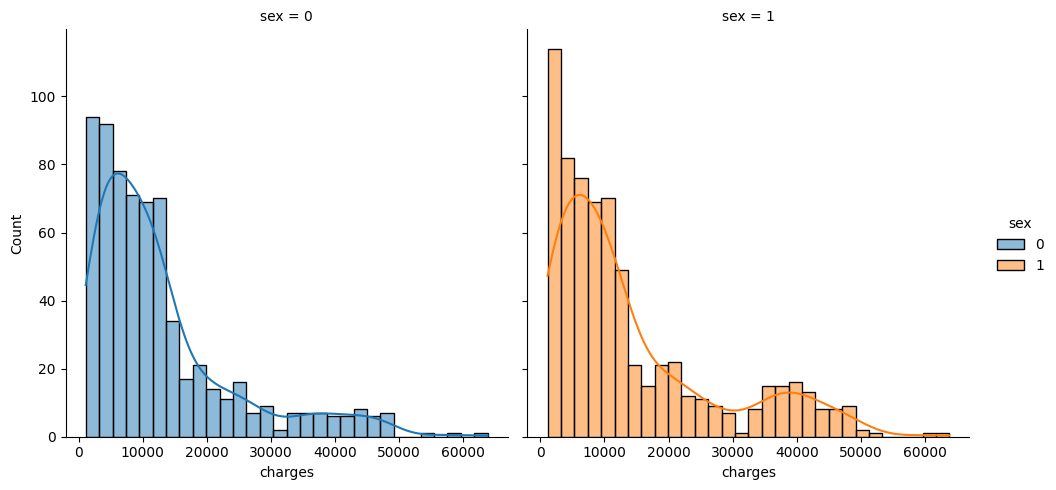

In [647]:
g= sns.displot(data = df, x = "charges",col = "sex", hue="sex", kind="hist", kde=True, aspect=1)

<h4 align = "center">1.3.3 Histogram of charges by smoker status </h4>

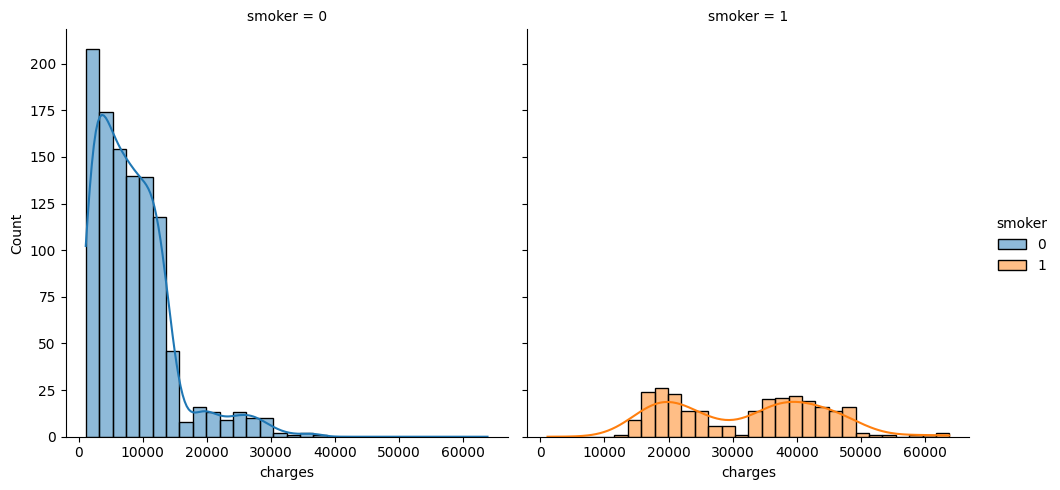

In [648]:
g= sns.displot(data = df, x = "charges",col = "smoker", hue="smoker", kind="hist", kde=True, aspect=1)

<h4 align = "center">1.3.4 Histogram of charges by region </h4>

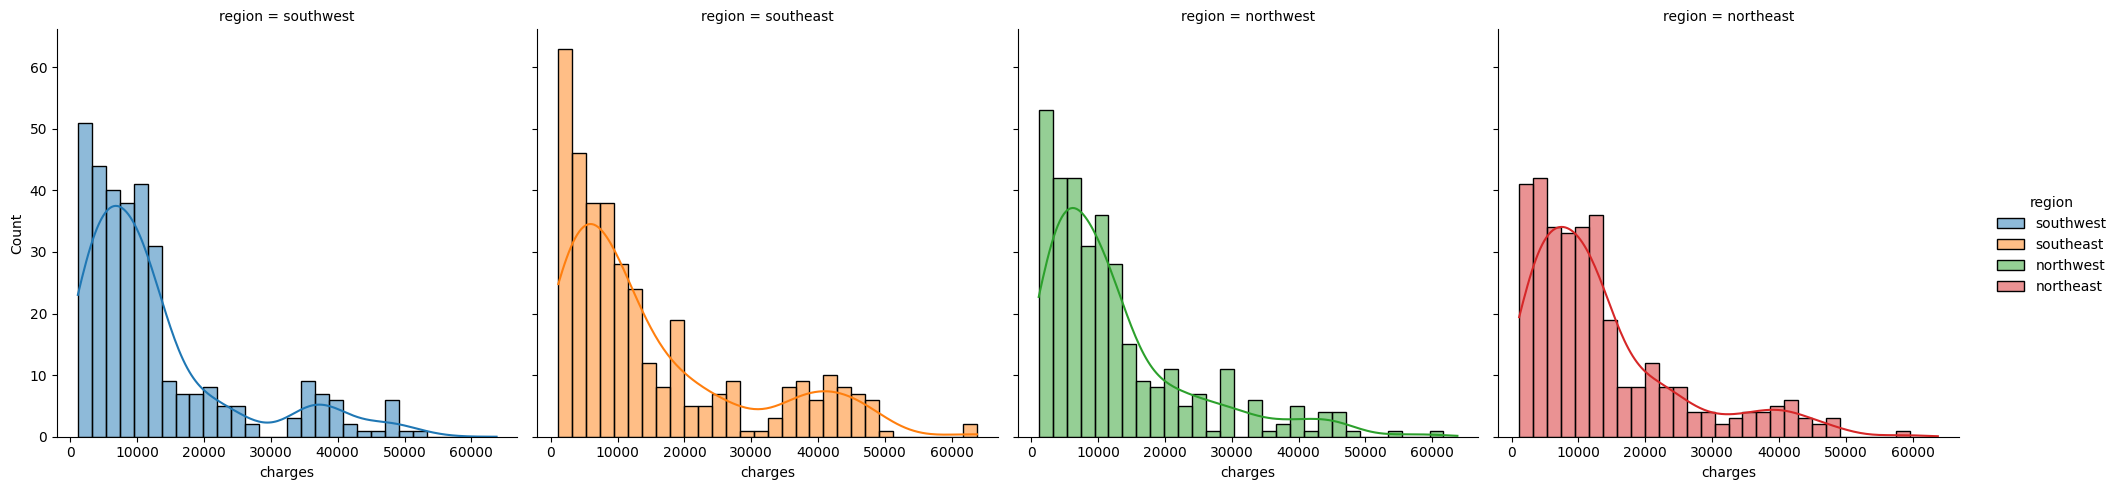

In [649]:
g = sns.displot(data = df, x="charges",col="region", hue="region", kind="hist", kde=True, aspect=1)

<h2 align = "center"> 2 Relationships between data </h2>
<p> this section is dedicated to the visualisations of the datapoints, how datapoints are scattered, what data has meaningful correlations etc

<h4 align = "center"> 2.1 Correlation heatmap </h4>
here we will get the R value of each intersection using Pearson s correlation

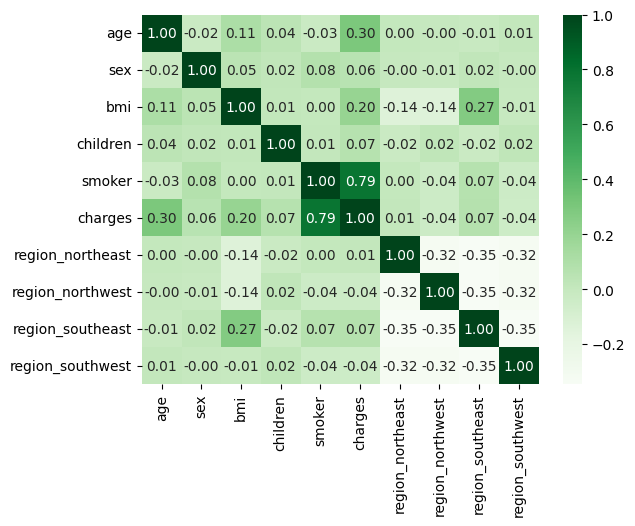

In [650]:
df = pd.get_dummies(df, columns=['region'], prefix='region')
corr= df.corr()
sns.heatmap(corr, annot=True,fmt=".2f", cmap="Greens")
#small trick to revert the df to it s original form for further operations *wink*
df = deepcopy(auxdf)


<h4 align = "center"> 2.2 Scatterplot of bmi and age</h4>
<p> shows the different points between age and bmi, we observe a very large amount of uneven residual spread, making my prediction interval very wide, despite seeming homoscedastic the data has very little value due to a very low R2.
Despite having a linear relationship, the value of the relationship is almost neglectable due to big residuals

The correlation coefficient (r) is: 0.109
The r squared is: 0.012


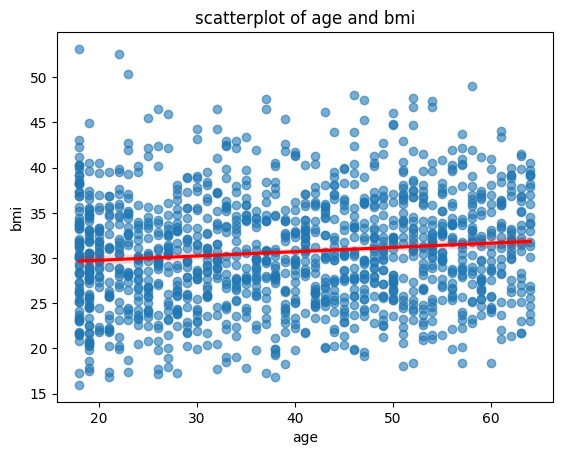

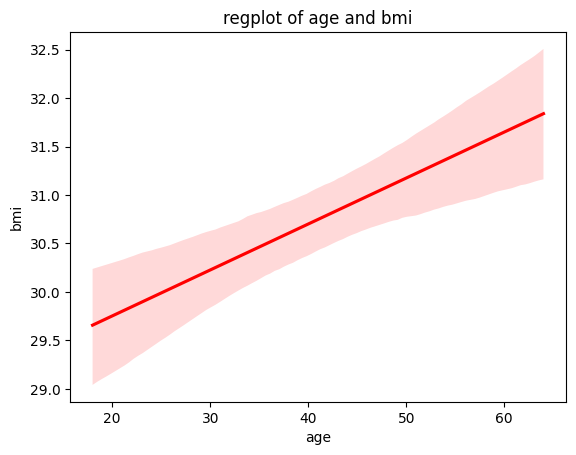

In [651]:
plt.figure()
sns.regplot(data=df, x="age", y="bmi", scatter_kws={'alpha':0.6},line_kws={"color": "red"})
plt.title("scatterplot of age and bmi")
plt.figure()
sns.regplot(data=df, x="age", y="bmi", scatter = False,line_kws={"color": "red"})
plt.title("regplot of age and bmi")
corr_val = df["age"].corr(df["bmi"])
print(f"The correlation coefficient (r) is: {corr_val:.3f}")
r_square = corr_val**2
print(f"The r squared is: {r_square:.3f}")

<h4 align = "center"> 2.3 Scatterplot of bmi and southwest</h4>
<p> this graph will just show you there is a difference between the means of the southeasteners and the other people in the dataset

The correlation coefficient (r) is: 0.109
The R squared is: 0.012


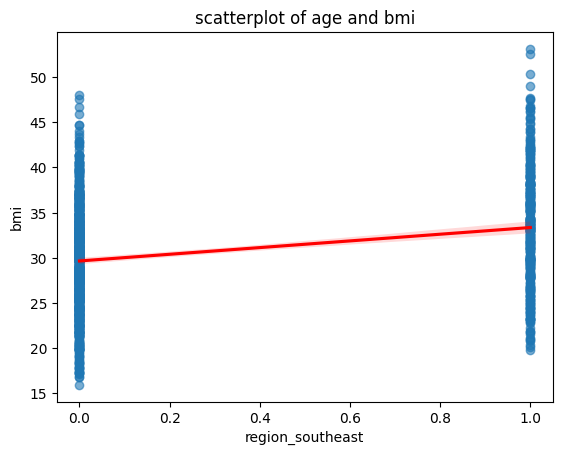

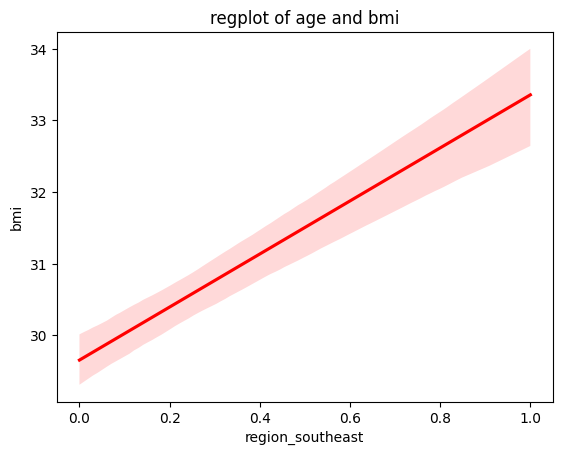

In [652]:
df = pd.get_dummies(df, columns=['region'], prefix='region')
plt.figure()
sns.regplot(data=df, x="region_southeast", y="bmi", scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})
plt.title("scatterplot of age and bmi")
plt.figure()
sns.regplot(data=df, x="region_southeast", y="bmi", scatter=False, line_kws={"color": "red"})
plt.title("regplot of age and bmi")
corr_val = df["age"].corr(df["bmi"])
R2 = corr_val**2
print(f"The correlation coefficient (r) is: {corr_val:.3f}")
print(f"The R squared is: {R2:.3f}")
df = deepcopy(auxdf)

<h4 align = "center"> 2.4 scatterplot of charges and bmi</h4>
<p> so, as you can see below, the R2 of non smokers bmis is 0.007, we can safely assume that the charges of a non smoker are not caused by bmi increase</p>
<p> the smoker situation on the other hand is much different, having an r2 of 0.65 compared to the non smokers of below 0.01, bmis seem to have a much bigger impact on charges for smokers, it is likely that charges are influenced by bmi

The correlation coefficient between smokers bmis and charges(r) is: 0.806
The R squared is: 0.650
The correlation coefficient between non smokers bmis and charges(r) is: 0.084
The R squared is: 0.007


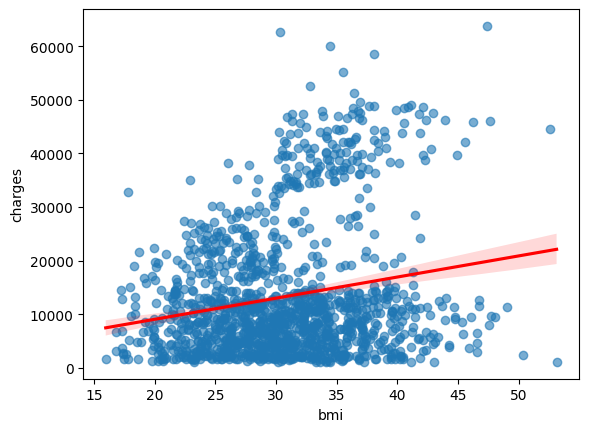

<Figure size 640x480 with 0 Axes>

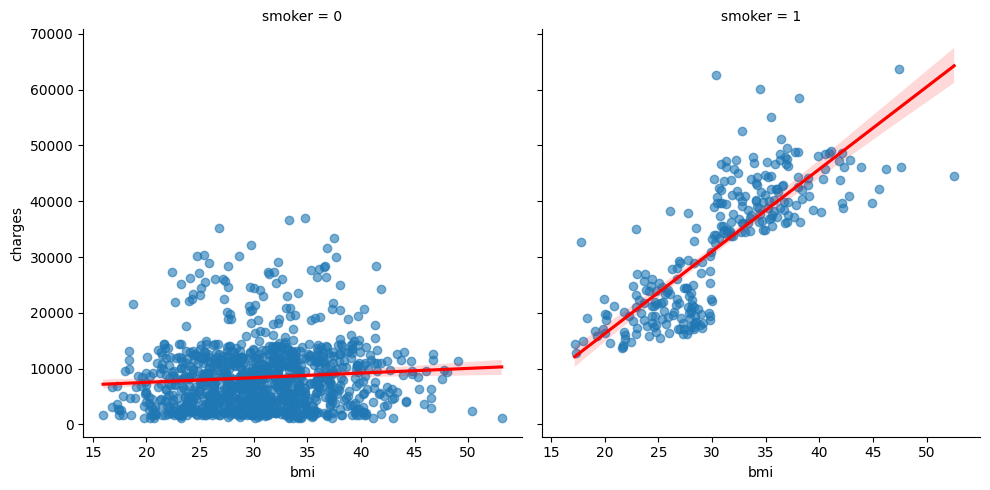

In [653]:
plt.figure()
sns.regplot(data=df, x="bmi", y="charges", scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})

plt.figure()
sns.lmplot(data=df, x="bmi", y="charges",col="smoker", scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})

smoker = df[df["smoker"] == 1]
corr_val = smoker["bmi"].corr(smoker["charges"])
r2 = corr_val ** 2
nonsmoker = df[df["smoker"] == 0]
corr_val2 = nonsmoker["bmi"].corr(nonsmoker["charges"])
r22 = corr_val2 ** 2
print(f"The correlation coefficient between smokers bmis and charges(r) is: {corr_val:.3f}")
print(f"The R squared is: {r2:.3f}")
print(f"The correlation coefficient between non smokers bmis and charges(r) is: {corr_val2:.3f}")
print(f"The R squared is: {r22:.3f}")


<h4 align = "center" > 2.5 Age and charges scatterplot </h4>
<p> as we can see aging for smokers is not the main cause of charge increments, since the R2 of smoker charges by age is quite small having 0.13
<p> on the other hand, age does a much better job at explaining why non smokers charges increase even with varying bmis

<Figure size 640x480 with 0 Axes>

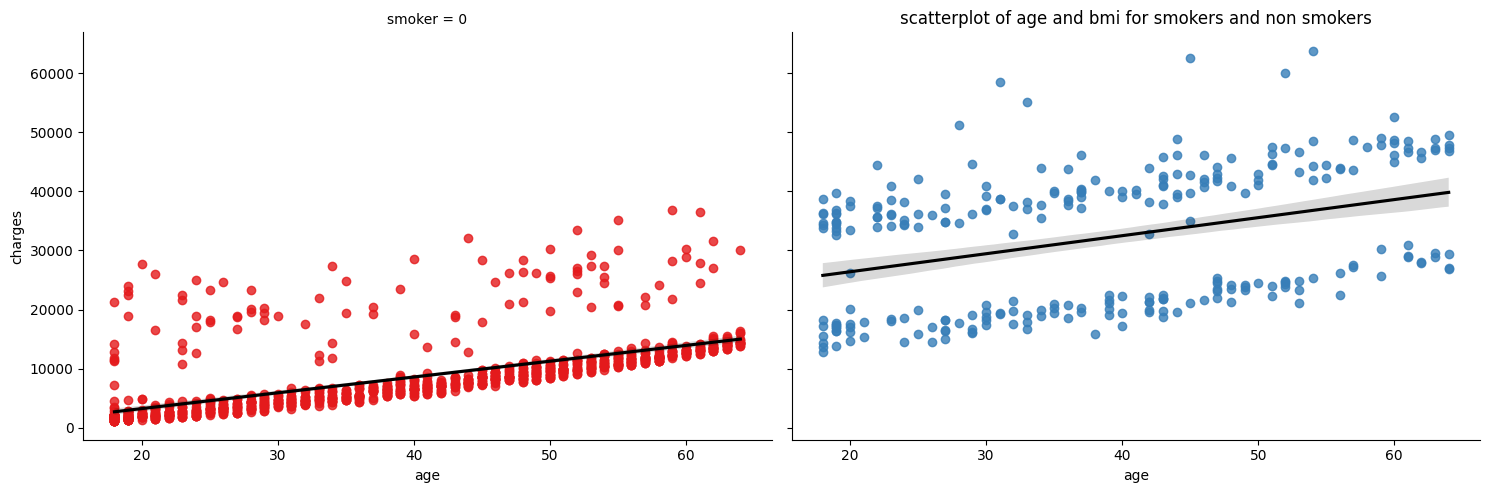

The correlation coefficient between smokers ages and charges(r) is: 0.368
The R squared is: 0.136
The correlation coefficient between non smokers ages and charges(r) is: 0.628
The R squared is: 0.394


In [654]:
plt.figure()
sns.lmplot(data=df, x="age", y="charges", hue="smoker", col="smoker", palette="Set1", aspect=1.5,
           line_kws={"color": "black"})
plt.title("scatterplot of age and bmi for smokers and non smokers")
plt.show()

smoker = df[df["smoker"] == 1]
corr_val = smoker["age"].corr(smoker["charges"])
r2 = corr_val ** 2
nonsmoker = df[df["smoker"] == 0]
corr_val2 = nonsmoker["age"].corr(nonsmoker["charges"])
r22 = corr_val2 ** 2
print(f"The correlation coefficient between smokers ages and charges(r) is: {corr_val:.3f}")
print(f"The R squared is: {r2:.3f}")
print(f"The correlation coefficient between non smokers ages and charges(r) is: {corr_val2:.3f}")
print(f"The R squared is: {r22:.3f}")

<h4 align = "center"> 2.6 Charges by age for each location </h4>
<p> we can see each of the 4 region has an R2 ranging from 0.06 to 0.11, whilst not the best values I will still try to incorporate them into predictions </p>

      age  sex     bmi  children  smoker     region      charges
0      19    0  27.900         0       1  southwest  16884.92400
1      18    1  33.770         1       0  southeast   1725.55230
2      28    1  33.000         3       0  southeast   4449.46200
3      33    1  22.705         0       0  northwest  21984.47061
4      32    1  28.880         0       0  northwest   3866.85520
...   ...  ...     ...       ...     ...        ...          ...
1333   50    1  30.970         3       0  northwest  10600.54830
1334   18    0  31.920         0       0  northeast   2205.98080
1335   18    0  36.850         0       0  southeast   1629.83350
1336   21    0  25.800         0       0  southwest   2007.94500
1337   61    0  29.070         0       1  northwest  29141.36030

[1338 rows x 7 columns]
0.25835787760143436 0.06674879291871774
0.31059315928465775 0.09646811059442478
0.3376538424947998 0.11401011735150307
0.3009512000834591 0.09057162483167423


<Figure size 640x480 with 0 Axes>

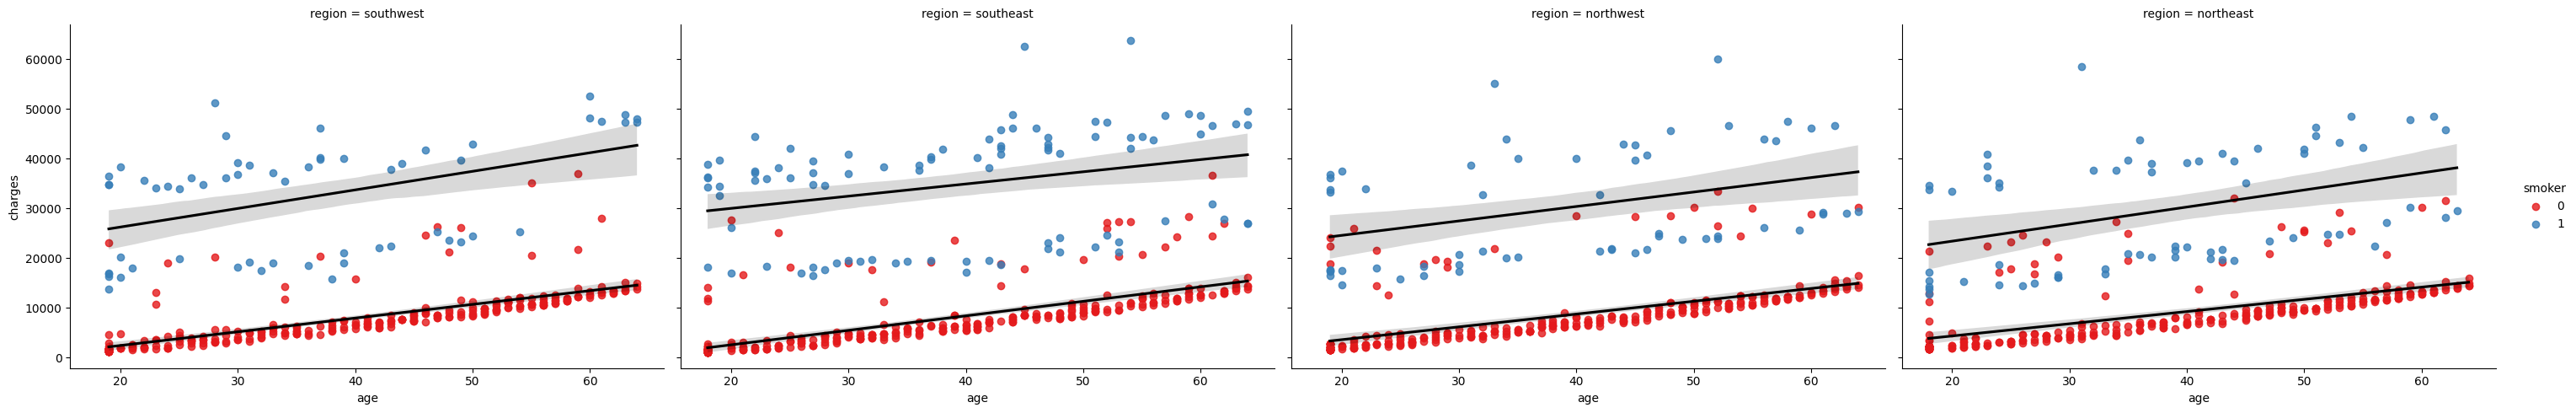

In [655]:
print(df)
plt.figure()
sns.lmplot(data = df, x = "age", y = "charges", hue = "smoker", col = "region", palette="Set1", aspect=1.5,line_kws={"color": "black"})

df = pd.get_dummies(df, columns=['region'], prefix='region')

sw = df[df["region_southwest"] == True]
corr_valsw = sw["age"].corr(sw["charges"])
r2sw = corr_valsw ** 2
print(corr_valsw,r2sw)

se = df[df["region_southeast"] == True]
corr_val = se["age"].corr(se["charges"])
r2 = corr_val ** 2
print(corr_val,r2)

nw = df[df["region_northwest"] == True]
corr_valnw = nw["age"].corr(nw["charges"])
r2nw = corr_valnw ** 2
print(corr_valnw,r2nw)

ne = df[df["region_northeast"] == True]
corr_valne = ne["age"].corr(ne["charges"])
r2ne = corr_valne ** 2
print(corr_valne,r2ne)
df = deepcopy(auxdf)


<h4 align = "center"> 3.1 simple model tournament </h4>
<p>
here we will create a tournament of predictive models, but, this being the simplest one, none will be tuned, the models will run on all the parameters, even with the risk of having entropy skew results. I will also not account for information gain at this step, .
<br>
Given the fact that this is my "baseline", I will compare future results to it by refferring to it as 3.1 or "baseline tournament"
</p>
<p> this will test the algorithms in an old school train test split of 70-30, and this results must be taken with a grain of salt since they can be a lucky guess </p>
<p> note that every model with close to .1 variance will be considered overfitted to the training set, also, high bias will also be treated as an issue. </p>

In [656]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor                    
from lightgbm import LGBMRegressor
from sklearn import metrics

df = pd.get_dummies(df, columns=['region'], prefix='region',drop_first=True)

X = df.drop(['charges'], axis=1)
y = df['charges']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=1.0),
    "Ridge": Ridge(alpha=3.0),
    "ElasticNet": ElasticNet(alpha=1.0),

    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=0),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=0),
    "Gradient Boosting": GradientBoostingRegressor(random_state=0),
    "AdaBoost": AdaBoostRegressor(random_state=0),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=0),
    "lightgbm" : LGBMRegressor(random_state=0, verbosity=-1),

}


print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} |  {"bias":<10}| {'MAE':<10}")
print("-" * 100)

for name, model in models.items():
    model.fit(X_train, Y_train)
    predictions = model.predict(X_test)

    train_r2 = model.score(X_train, Y_train)
    r2 = model.score(X_test, Y_test)

    bias = 1 - train_r2
    variance =  train_r2 - r2
    mae = metrics.mean_absolute_error(Y_test, predictions)

    print(f"{name:<20}   | {train_r2:.4f}   |   {r2:.4f}   |  {variance:.4f}    |   {bias:.2f}   |   ${mae:.2f}")

df = deepcopy(auxdf)


Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE       
----------------------------------------------------------------------------------------------------
Linear Regression      | 0.7424   |   0.7696   |  -0.0272    |   0.26   |   $4145.45
Lasso                  | 0.7424   |   0.7696   |  -0.0272    |   0.26   |   $4145.98
Ridge                  | 0.7422   |   0.7687   |  -0.0265    |   0.26   |   $4185.20
ElasticNet             | 0.3871   |   0.4041   |  -0.0170    |   0.61   |   $7332.13
Bayesian Ridge         | 0.7424   |   0.7695   |  -0.0271    |   0.26   |   $4152.75
Decision Tree          | 0.8771   |   0.8560   |  0.0211    |   0.12   |   $2716.13
Random Forest          | 0.9744   |   0.8545   |  0.1198    |   0.03   |   $2602.62
Extra Trees            | 1.0000   |   0.8314   |  0.1686    |   0.00   |   $2580.70
Gradient Boosting      | 0.9040   |   0.8656   |  0.0385    |   0.10   |   $2491.96
AdaBoost               | 0.8285   |   0.8092   

as you can see the results are horrible overall<br> starting from the top down, let s see what we can extrapolate from these results  <br>
1 linear regression - the accuracy obtained is decent, not flattering, what is interesting is the negative variance, wich simply tells us the model had a better fit on the test data than the train data, the fact that variance is so small indicates we are not overfitting. Taking a look at variance we might actually say the model is undefit, having a very high bias means it does not efficiently
<br>
2 for ridge regression, we have an issue, since variance and bias stays the same, we are basically using a line very similar to the linear one, to the point that it does not really matter.
The cause of this effect is the very small penalty applied, here labda is 1 wich is apparently too small
<br>
3 Lasso, being very similar to ridge, performed almost the same as ridge, their only difference is the way they handle the slope and the fact that lasso can eliminate non contributing feautures. That being said, the likelihood that my dataset has no useless attributes is quite high, the fact that ridge and lasso are so similar point towards that too, it also tells us the dataset has low noise.
<br><b>note that regularization (lasso ridge and elastic net) works way better with a lot of attributes (50+ for example) because some will likely be useless and it is also better at handling outliers.</b><br>
4 elastic net is also a regularization one, but it is a combination of both ridge and lasso, the funny thing is that combinging the 2 with the standard 1 lambda make the model so strict it will have a horrible output, due to it s strictness it heavily underfitted <br>
NOTE! using elastic net was actually just an experiment for fun, I will refrain from using it in future tests because it would be like using a bazooka to drill a hole for a nail



In [657]:
df['bmi_smoker'] = df['bmi'] * df['smoker']

df = pd.get_dummies(df, columns=['region'], prefix='region',drop_first=True)

X = df.drop(['charges'], axis=1)
y = df['charges']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.4, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=1.0),
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0),
    "Bayesian Ridge": BayesianRidge(),

    # --- The Tree & Ensemble Family (High Accuracy) ---
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Gradient Boosting": GradientBoostingRegressor(random_state=0),
    "lightgbm" : LGBMRegressor(random_state=0, verbosity=-1),
    "Random Forest (Tuned)": RandomForestRegressor(n_estimators=200, max_depth=7, max_features='sqrt', random_state=0),
    "Extra Trees (Tuned)": ExtraTreesRegressor(n_estimators=200, max_depth=7, min_samples_leaf=5, random_state=0),
    "XGBoost (Tuned)": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.7, colsample_bytree=0.7, reg_lambda=100,random_state=0),
    "Hist Grad Boost (Tuned)": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=5),
    "AdaBoost (Tuned)": AdaBoostRegressor(n_estimators=50, learning_rate=0.5, random_state=0),

}


print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} |  {"bias":<10}| {'MAE':<10}")
print("-" * 100)

for name, model in models.items():
    model.fit(X_train, Y_train)

    predictions = model.predict(X_test)
    train_r2 = model.score(X_train, Y_train)
    r2 = model.score(X_test, Y_test)
    bias = 1 - train_r2
    variance =  train_r2 - r2
    mae = metrics.mean_absolute_error(Y_test, predictions)

    print(f"{name:<20}   | {train_r2:.4f}   |   {r2:.4f}   |  {variance:.4f}    |   {bias:.2f}   |   ${mae:.2f}")

df = deepcopy(auxdf)

Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE       
----------------------------------------------------------------------------------------------------
Linear Regression      | 0.8325   |   0.8509   |  -0.0184    |   0.17   |   $2799.32
Lasso                  | 0.8325   |   0.8510   |  -0.0185    |   0.17   |   $2799.43
Ridge                  | 0.8319   |   0.8517   |  -0.0198    |   0.17   |   $2790.28
ElasticNet             | 0.8118   |   0.8347   |  -0.0229    |   0.19   |   $3096.79
Bayesian Ridge         | 0.8323   |   0.8516   |  -0.0193    |   0.17   |   $2792.56
Decision Tree          | 0.8761   |   0.8477   |  0.0284    |   0.12   |   $2720.26
Gradient Boosting      | 0.9123   |   0.8557   |  0.0566    |   0.09   |   $2596.51
lightgbm               | 0.9443   |   0.8469   |  0.0974    |   0.06   |   $2810.75
Random Forest (Tuned)   | 0.9121   |   0.8618   |  0.0502    |   0.09   |   $2634.15
Extra Trees (Tuned)    | 0.8869   |   0.8677  

the R2 difference between my first regression where I estimate based on age and if they smoke or not and the second one where i also consider their sex and bmi is small
first reg R2 = 0.7214008260577199
second reg R2 = 0.7474972680928911
in .3f the difference is 0.026, this I can confidently say the bmi and sex do not influence charges a lot, even tho my correlation for bmi and charges is 0.1

In [658]:

import numpy as np
import pandas as pd
import os
import kagglehub
from copy import deepcopy
from sklearn import metrics
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              ExtraTreesRegressor, AdaBoostRegressor,
                              HistGradientBoostingRegressor)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

# --- 1. DATA LOADING & INITIAL PREPROCESSING ---
path = kagglehub.dataset_download("mirichoi0218/insurance")
df = pd.read_csv(f"{path}/insurance.csv")

# Save a clean copy for resets
auxdf = deepcopy(df)

# Basic encoding for binary variables
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# Feature Engineering
df['bmi_smoker'] = df['bmi'] * df['smoker']

# One-Hot Encoding for Region (creating the dummies)
df = pd.get_dummies(df, columns=['region'], prefix='region', drop_first=True)

# Define X and y
X = df.drop(['charges'], axis=1, errors='ignore')
y = df['charges']

# --- 2. MODEL DEFINITIONS ---
# Note: Alpha is reduced for Lasso/ElasticNet because target values are now smaller (Log scale)
models = {
    "Linear Regression": LinearRegression(),
    "Lasso (Tuned Alpha)": Lasso(alpha=0.001),
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.001),
    "Bayesian Ridge": BayesianRidge(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Gradient Boosting": GradientBoostingRegressor(random_state=0),
    "lightgbm (tuned)": LGBMRegressor(random_state=0, verbosity=-1, num_leaves=20, max_depth=5),
    "Random Forest (Tuned)": RandomForestRegressor(n_estimators=200, max_depth=7, max_features='sqrt', random_state=0),
    "Extra Trees (Tuned)": ExtraTreesRegressor(n_estimators=200, max_depth=7, min_samples_leaf=5, random_state=0),
    "XGBoost (Tuned)": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.7, colsample_bytree=0.7, reg_lambda=100, random_state=0),
    "Hist Grad Boost (Tuned)": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=5),
    "AdaBoost (Tuned)": AdaBoostRegressor(n_estimators=50, learning_rate=0.5, random_state=0),
}

# --- 3. CROSS-VALIDATION LOOP WITH LOG-SCALING ---
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scaler = StandardScaler()

print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} | {'Bias':<10} | {'MAE':<10}")
print("-" * 110)

model_residuals = {}

for name, model in models.items():
    f_train_r2, f_test_r2, f_mae, f_variance, f_bias = [], [], [], [], []

    for train_index, test_index in kf.split(X):
        # Split
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        # A. SCALE FEATURES
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_fold), columns=X.columns)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test_fold), columns=X.columns)

        # B. LOG TRANSFORM TARGET
        y_train_log = np.log1p(y_train_fold)

        # C. FIT MODEL
        model.fit(X_train_scaled, y_train_log)

        # D. PREDICT & INVERSE TRANSFORM (Back to dollars)
        train_log_preds = model.predict(X_train_scaled)
        test_log_preds = model.predict(X_test_scaled)

        train_preds = np.expm1(train_log_preds)
        test_preds = np.expm1(test_log_preds)

        # E. CALCULATE METRICS (On original dollar scale)
        tr_r2 = r2_score(y_train_fold, train_preds)
        te_r2 = r2_score(y_test_fold, test_preds)
        mae = metrics.mean_absolute_error(y_test_fold, test_preds)

        f_train_r2.append(tr_r2)
        f_test_r2.append(te_r2)
        f_variance.append(tr_r2 - te_r2)
        f_bias.append(1 - tr_r2)
        f_mae.append(mae)

        # Save residuals for the last fold (for visualization)
        model_residuals[name] = {
            'true': y_test_fold,
            'pred': test_preds,
            'res': y_test_fold - test_preds
        }

    # F. PRINT RESULTS
    print(f"{name:<25} | {np.mean(f_train_r2):.4f}   | {np.mean(f_test_r2):.4f}   | {np.mean(f_variance):.4f}    | {np.mean(f_bias):.2f}       | ${np.mean(f_mae):.2f}")

# Reset DF for next cell use
df = deepcopy(auxdf)

Model                     | Train R2   | Test R2    | Variance   | Bias       | MAE       
--------------------------------------------------------------------------------------------------------------
Linear Regression         | 0.4817   | 0.4665   | 0.0152    | 0.52       | $4160.41
Lasso (Tuned Alpha)       | 0.4882   | 0.4730   | 0.0152    | 0.51       | $4138.53
Ridge                     | 0.4865   | 0.4714   | 0.0151    | 0.51       | $4152.26
ElasticNet                | 0.4880   | 0.4729   | 0.0151    | 0.51       | $4144.30
Bayesian Ridge            | 0.4942   | 0.4793   | 0.0149    | 0.51       | $4138.98
Decision Tree             | 0.8754   | 0.8437   | 0.0317    | 0.12       | $2306.78
Gradient Boosting         | 0.8874   | 0.8466   | 0.0408    | 0.11       | $2146.97
lightgbm (tuned)          | 0.8944   | 0.8499   | 0.0445    | 0.11       | $2186.33
Random Forest (Tuned)     | 0.8887   | 0.8504   | 0.0383    | 0.11       | $2133.13
Extra Trees (Tuned)       | 0.8776   | 0.8

               age        bmi
cluster                      
0        49.831522  26.748043
1        52.490625  36.406406
2        26.872611  35.189729
3        26.446429  25.252143


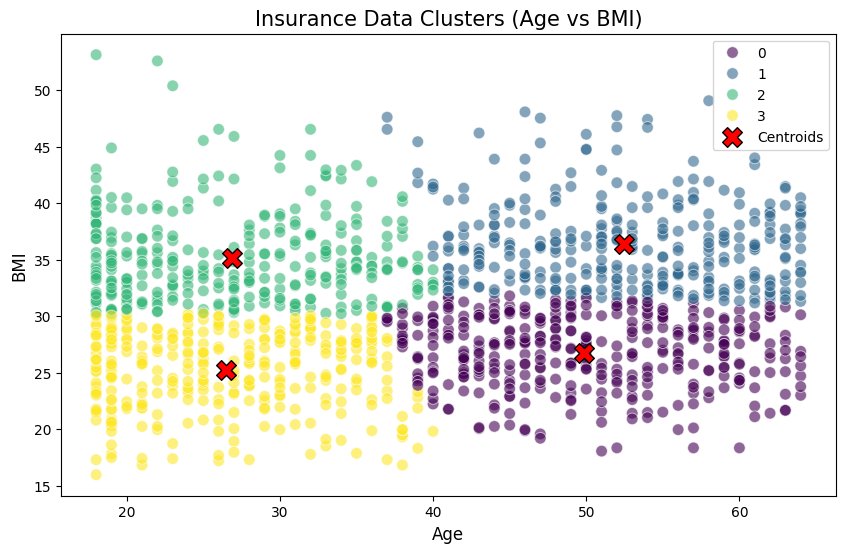

In [659]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ["age", "bmi"]
X = df[features]

# 2. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Clustering
kmeans = KMeans(n_clusters=4, n_init="auto", random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Print results
print(df.groupby('cluster')[features].mean())

# 5. Visualization (Age vs BMI)
plt.figure(figsize=(10, 6))

# Plotting Age vs BMI because these are your actual features
sns.scatterplot(data=df, x='age', y='bmi', hue='cluster', palette='viridis', s=70, alpha=0.6)

# 6. Get the centroids back to original scale
# Index 0 = age, Index 1 = bmi, Index 2 = smoker_val
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Plot the centroids using Age (index 0) and BMI (index 1)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='red', marker='X', s=200, label='Centroids', edgecolors='black')

plt.title('Insurance Data Clusters (Age vs BMI)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('BMI', fontsize=12)
plt.legend()
plt.show()



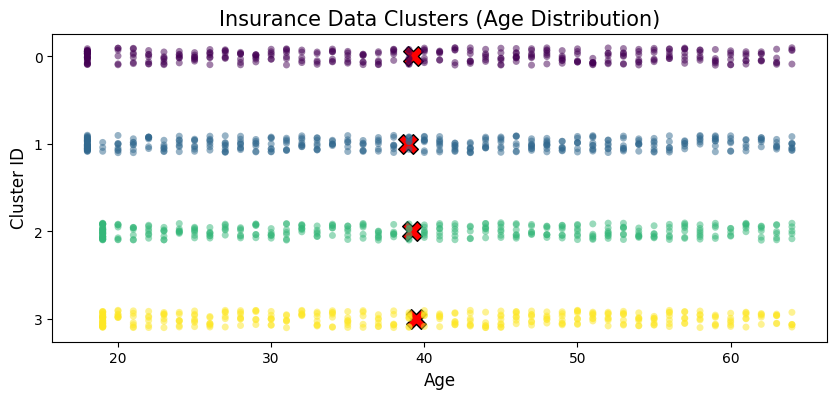

--- Cluster Profiles (Means of all features) ---
               age  region_northwest  region_southeast  region_southwest  \
cluster                                                                    
0        39.268519               0.0               0.0               0.0   
1        38.939560               0.0               1.0               0.0   
2        39.196923               1.0               0.0               0.0   
3        39.455385               0.0               0.0               1.0   

         region_northeast  
cluster                    
0                     1.0  
1                     0.0  
2                     0.0  
3                     0.0  


In [660]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
df = pd.get_dummies(df, columns=['region'], prefix='region')
# 1. Setup Features (BMI is gone)
feautures2 = ["age", "region_northwest", "region_southeast", "region_southwest", "region_northeast"]
Y = df[feautures2]

# 2. Scaling
scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y)

# 3. Clustering
kmeans = KMeans(n_clusters=4, n_init="auto", random_state=42)
df['cluster'] = kmeans.fit_predict(Y_scaled)

# 4. Visualization (Age Scatterplot - Ignoring BMI)
plt.figure(figsize=(10, 4))

# We plot Age on X, and Cluster on Y to see the age distribution of each group
sns.stripplot(data=df, x='age', y='cluster', hue='cluster',
              palette='viridis', orient='h', size=5, alpha=0.5, legend=False)

# 5. Centroids (Back to original scale)
# Since 'age' is index 0 in your feautures2 list:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], range(4),
            c='red', marker='X', s=200, label='Age Centroids', edgecolors='black')

plt.title('Insurance Data Clusters (Age Distribution)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Cluster ID', fontsize=12)
plt.show()

# 6. Print Results
print("--- Cluster Profiles (Means of all features) ---")
print(df.groupby('cluster')[feautures2].mean())

df=deepcopy(auxdf)

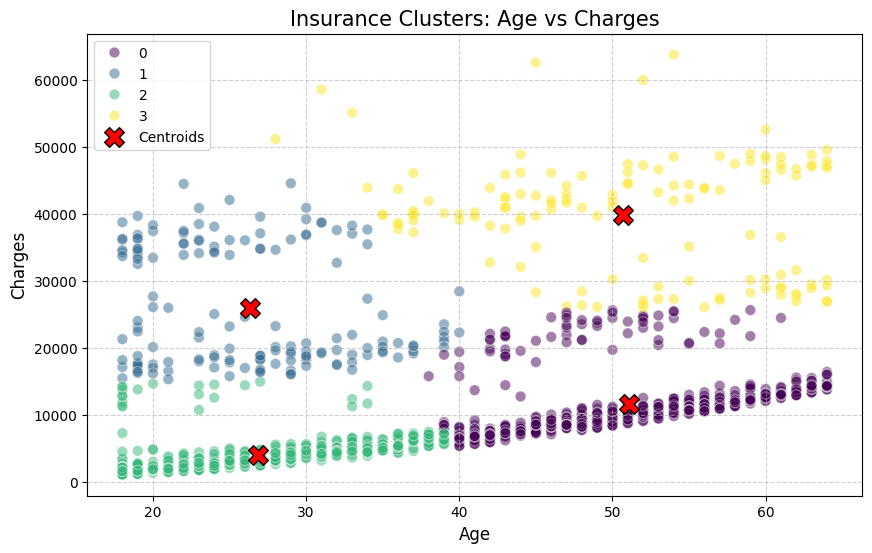

--- Cluster Profiles ---
               age       charges
cluster                         
0        51.082734  11664.536743
1        26.342105  25994.596050
2        26.825301   4129.751867
3        50.712121  39867.784333


In [661]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Setup Features
features3 = ["age", "charges"]
Z = df[features3]

# 2. Scaling
scaler = StandardScaler()
Z_scaled = scaler.fit_transform(Z)

# 3. Clustering
kmeans = KMeans(n_clusters=4, n_init="auto", random_state=42)
df['cluster'] = kmeans.fit_predict(Z_scaled)

# 4. Visualization (Age vs Charges)
plt.figure(figsize=(10, 6))

# FIX: Use scatterplot instead of stripplot for continuous data like 'charges'
sns.scatterplot(data=df, x='age', y='charges', hue='cluster',
                palette='viridis', s=60, alpha=0.5)

# 5. Centroids (Back to original scale)
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

# FIX: Plot Y as centroids_original[:, 1] (Charges) so they line up with the dots
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='red', marker='X', s=200, label='Centroids', edgecolors='black', zorder=10)

plt.title('Insurance Clusters: Age vs Charges', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Print Results
print("--- Cluster Profiles ---")
print(df.groupby('cluster')[features3].mean())